# Reference

[data](https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset)

# Import

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

import plotly.express as px

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Data

In [75]:
df = pd.read_csv('../../../delete/insurance.csv')

In [76]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

- Insurance distribution

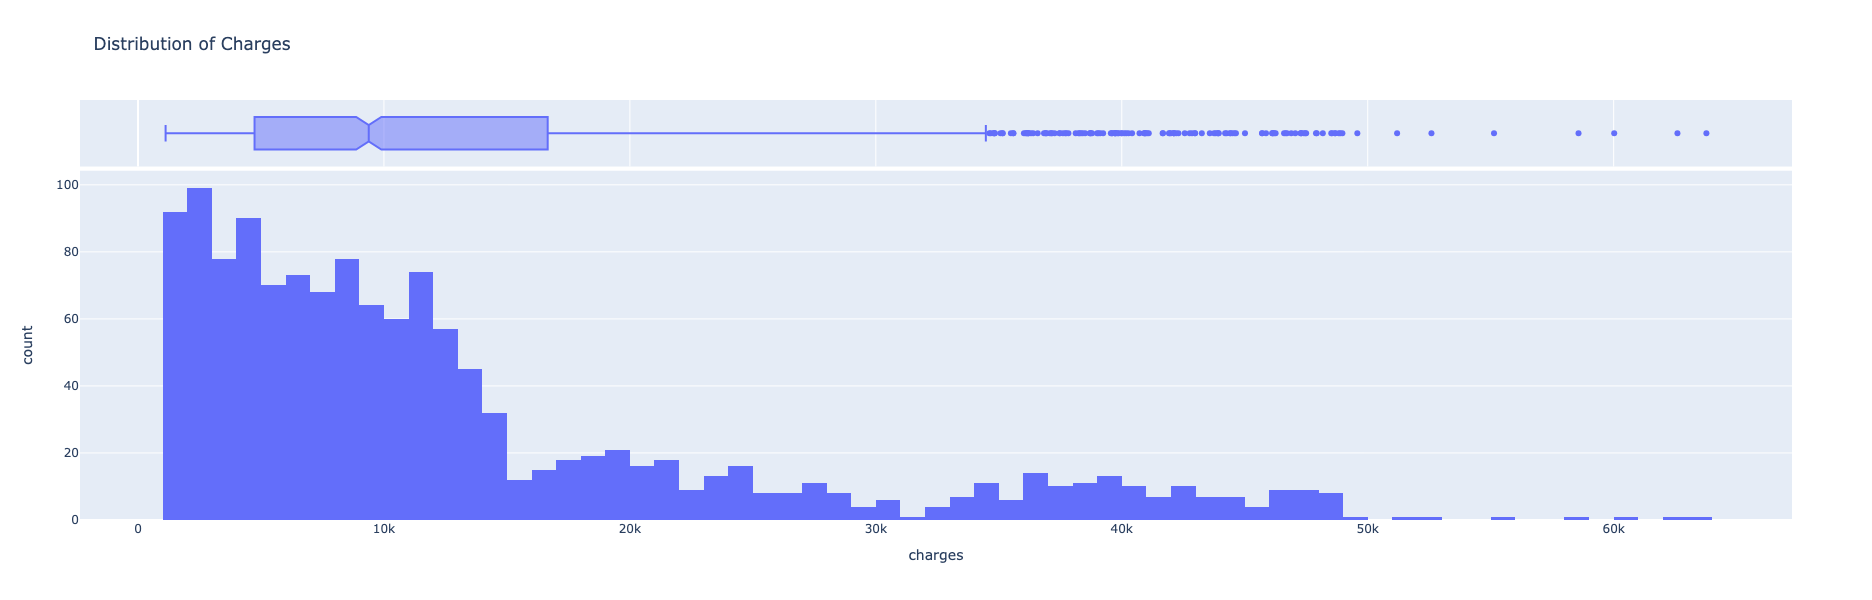

In [77]:
fig = px.histogram(df, x="charges",
                   nbins=80,
                   marginal="box",
                   title="Distribution of Charges",
                   width=800, height=600)
fig.show()

- age vs insurance
    - mouse over 했을때, sex, region도 같이 나타남

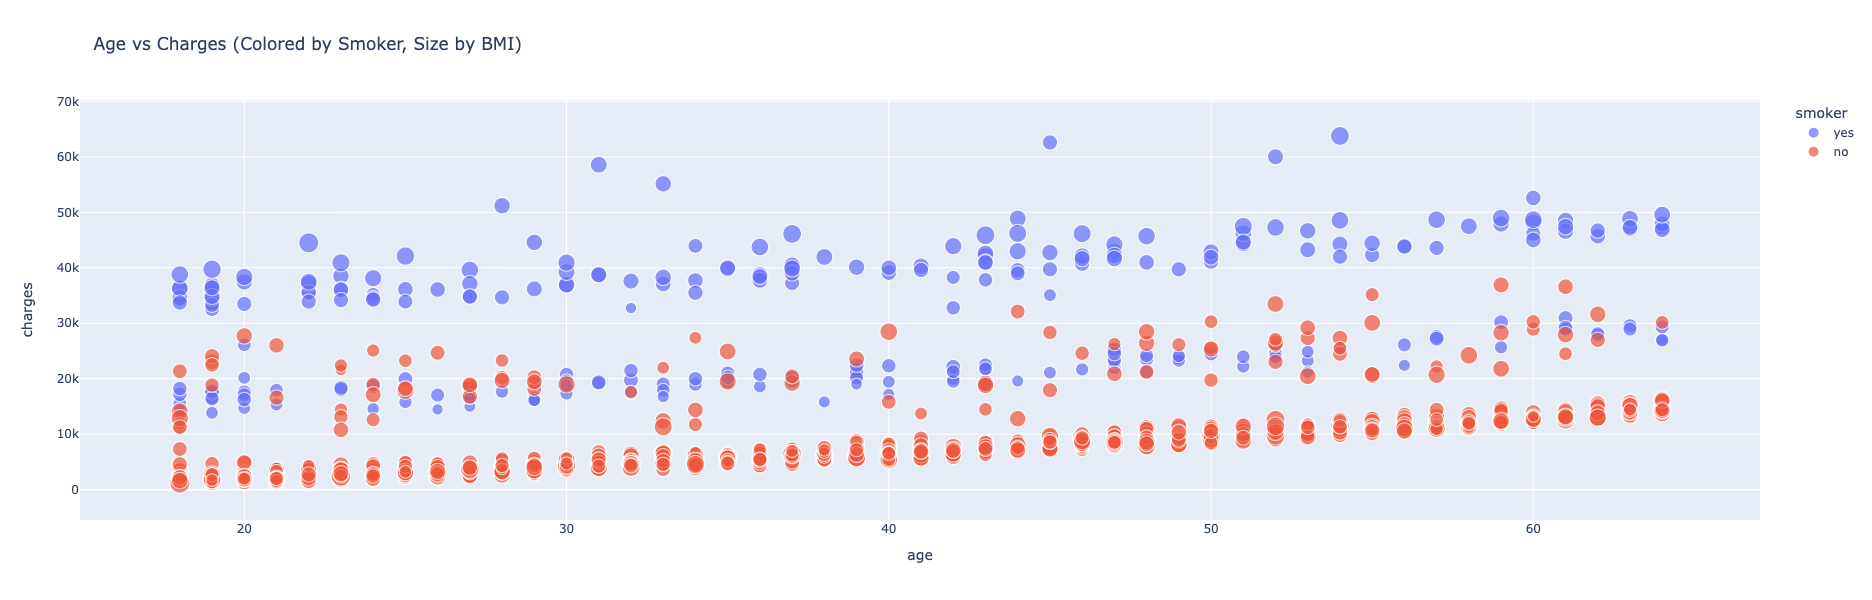

In [78]:
fig = px.scatter(df, x="age", y="charges", color="smoker",
                 size="bmi", hover_data=["sex", "region"],
                 title="Age vs Charges (Colored by Smoker, Size by BMI)",
                 width=800, height=600)
fig.show()

- BMI vs insurance

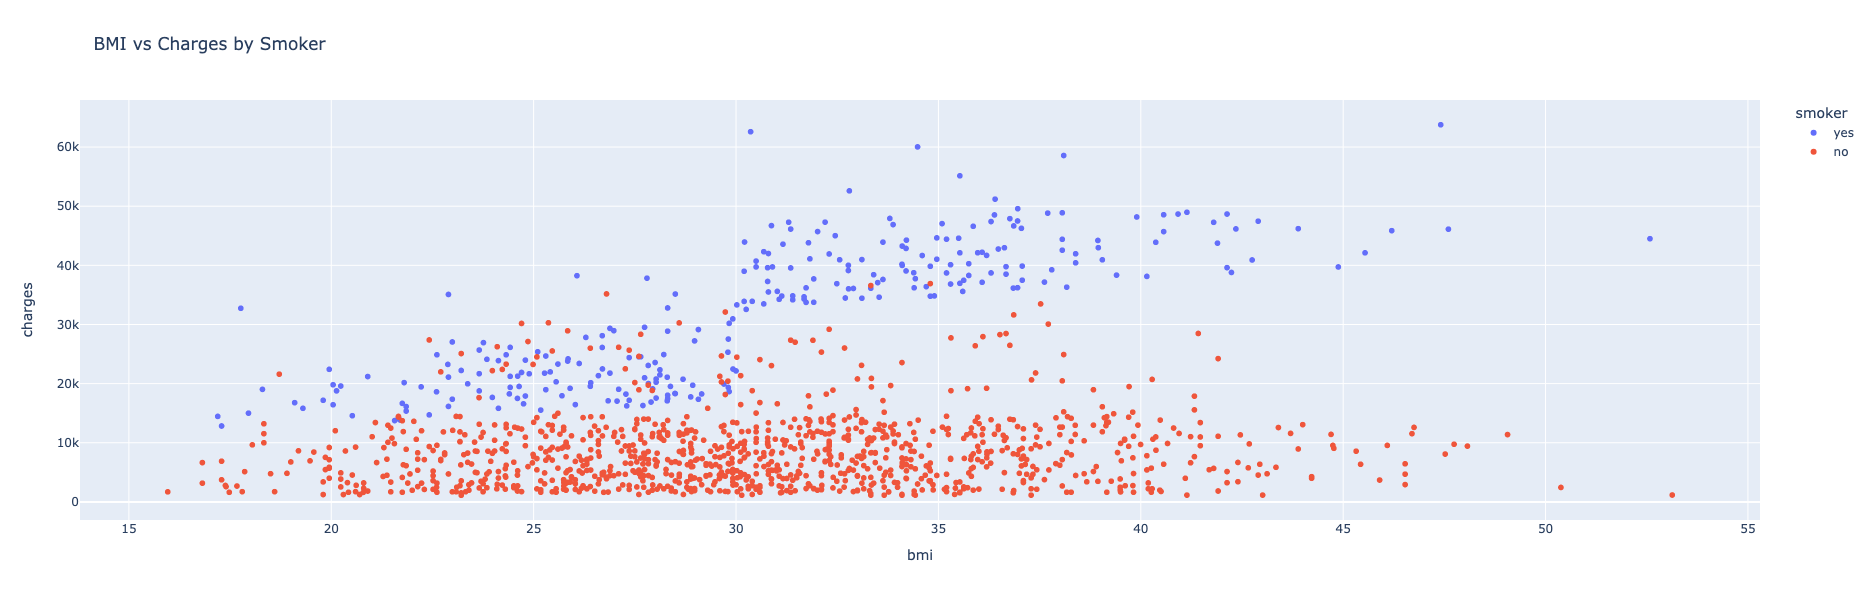

In [79]:
fig = px.scatter(df, x="bmi", y="charges", color="smoker",
                 hover_data=["age", "sex"],
                 title="BMI vs Charges by Smoker",
                 width=800, height=600)
fig.show()

- average insurance by regions

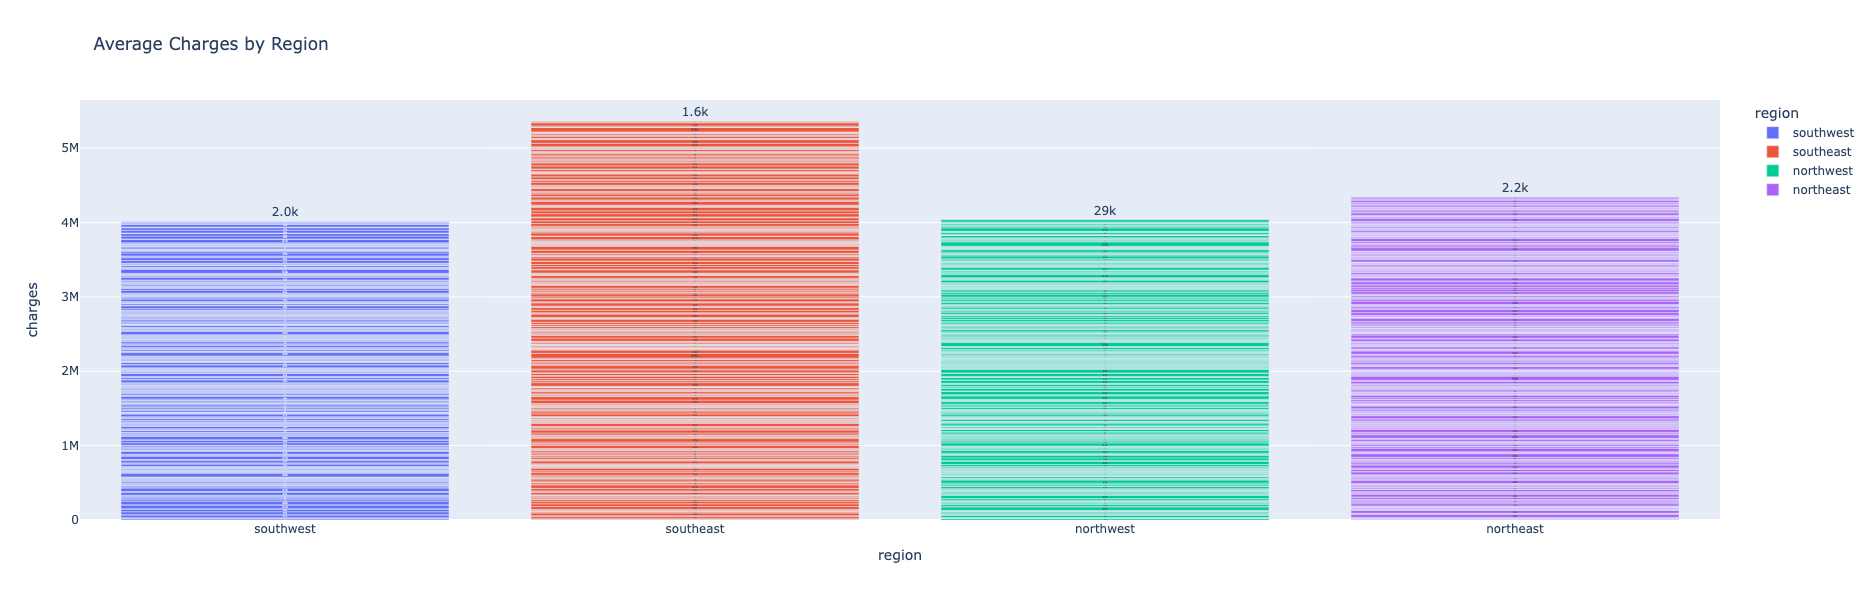

In [85]:
fig = px.bar(df, x="region", y="charges", color="region",
             title="Average Charges by Region",
             # barmode="group",
             hover_data=["region"], 
             text_auto=".2s",
             width=800, height=600)
fig.show()

# Train via Pytorch

In [86]:
categorical_cols = ["sex", "smoker", "region"]

In [87]:
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

- 변환된 데이터(명목형->연속형)

In [88]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


In [89]:
X = df.drop("charges", axis=1).values
y = df["charges"].values

In [90]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [91]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 모델 정의

In [93]:
class InsuranceModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X.shape[1], 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x) # activation을 넣지 않은 이유는 회귀라서
        return x

In [94]:
model = InsuranceModel()

In [95]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 학습

In [109]:
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        val_loss = criterion(model(X_test), y_test).item()
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {loss.item():.4f}, Test Loss: {val_loss:.4f}")

Epoch [10/1000] Train Loss: 27651742.0000, Test Loss: 25587464.0000
Epoch [20/1000] Train Loss: 27516590.0000, Test Loss: 25459822.0000
Epoch [30/1000] Train Loss: 27380854.0000, Test Loss: 25330672.0000
Epoch [40/1000] Train Loss: 27245306.0000, Test Loss: 25200350.0000
Epoch [50/1000] Train Loss: 27110060.0000, Test Loss: 25069516.0000
Epoch [60/1000] Train Loss: 26974262.0000, Test Loss: 24936696.0000
Epoch [70/1000] Train Loss: 26836122.0000, Test Loss: 24801114.0000
Epoch [80/1000] Train Loss: 26695746.0000, Test Loss: 24663712.0000
Epoch [90/1000] Train Loss: 26554166.0000, Test Loss: 24524616.0000
Epoch [100/1000] Train Loss: 26411714.0000, Test Loss: 24384058.0000
Epoch [110/1000] Train Loss: 26267990.0000, Test Loss: 24242138.0000
Epoch [120/1000] Train Loss: 26123302.0000, Test Loss: 24099886.0000
Epoch [130/1000] Train Loss: 25978182.0000, Test Loss: 23958424.0000
Epoch [140/1000] Train Loss: 25833168.0000, Test Loss: 23818406.0000
Epoch [150/1000] Train Loss: 25688288.0000,

In [110]:
model.eval()

InsuranceModel(
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

In [111]:
with torch.no_grad():
    preds = model(X_test)
    y_pred = preds.numpy().flatten()
    y_true = y_test.numpy().flatten()
    print("샘플 예측:", preds[:5].flatten())
    print("실제 값:", y_test[:5].flatten())

샘플 예측: tensor([ 9970.7197,  6313.5679, 32748.6152, 10189.2920, 30496.3457])
실제 값: tensor([ 9095.0684,  5272.1758, 29330.9824,  9301.8936, 33750.2930])


In [112]:
result_df = pd.DataFrame({"Actual": y_true, "Predicted": y_pred})

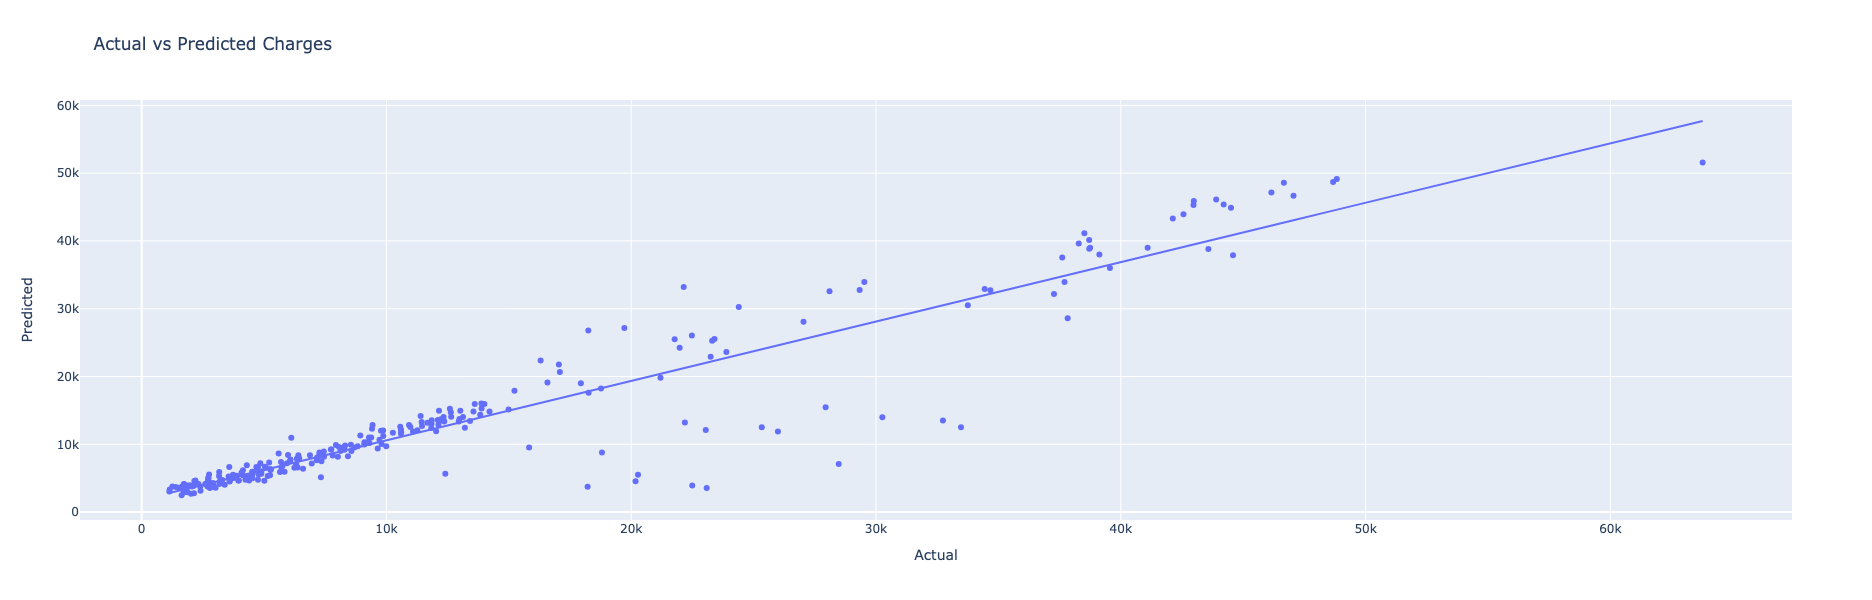

In [113]:
fig = px.scatter(result_df, x="Actual", y="Predicted",
                 trendline="ols",  
                 title="Actual vs Predicted Charges",
                 width=800, height=600)
fig.show()